# Neural Networks for Regression

Linear regression, random forests, and gradient boosting all learn a mapping from features to a
continuous target. A **neural network** does the same thing, but it builds that mapping by stacking
many simple linear-plus-nonlinearity steps on top of each other. This notebook is our first look at
Keras: we build a network on synthetic 1-D data where we can *see* the fit, train it, read the loss
curve, watch what it does outside the training range, and draw the learned weights as a picture.

## Learning objectives

- Describe a feedforward network as a stack of affine transformations and activation functions
- Explain why a regression network ends in a single **linear** unit rather than a softmax
- Build, compile, and fit a `Sequential` model in Keras
- Read a training/validation loss curve and diagnose the fit
- Visualize a trained network's weights as a graph, and watch them change during training
- Recognize that a network only interpolates: it has no obligation to behave outside the training range

## Background

This notebook assumes the train/test split and the loss metrics (MSE, MAE) used throughout section
3, and the general problem of fitting a flexible model to noisy data — the same setting as
`U1-3_Regression-1_ModelCompare`, where an `MLPRegressor` already appeared as one family among
several. Here that model gets built explicitly rather than called in one line.

Everything specific to networks — architecture, activations, the output layer, the loss,
backpropagation, and the Adam optimizer — is developed in section 3, beside the code that uses it.

## This notebook covers

1. A drawing tool that renders any Keras model as a weighted graph
2. Generating a 1-D regression dataset we can plot
3. Building, training, and evaluating two networks of different depth
4. Extrapolating past the edges of the training data
5. Replacing the hand-written training loop with the shared course helper
6. Animating the fit and the weights, epoch by epoch

**Prerequisites:** `U1-3_Regression-1_ModelCompare` (train/test split, model families, the
extrapolation failure revisited in section 3.7), `U1-3_Regression-2_Overfitting` (reading a
train-versus-validation gap)

**Dataset:** none — synthetic 1-D data generated in the notebook. Three generators are available in
both section 2 and the animation in section 5, selected by toggling which lines are commented: a
**line**, a **sine wave**, or a **smoothed random walk**.

**References:** https://keras.io/guides/sequential_model/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)
pd.set_option("display.precision", 4)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. A tool for seeing the network

`model.summary()` tells us the *shape* of a network but nothing about what it has learned. The
three functions below turn any `Sequential` stack of `Dense` layers into a picture:

- `_get_model_graph_data` walks the layers and pulls out the neuron counts, the weight matrices,
  and a readable label for each layer.
- `_draw_network_on_ax` uses **networkx** to lay the neurons out in columns and draw one edge per
  weight. Edge **color** encodes sign (blue positive, red negative) and edge **width** encodes
  magnitude, so a strong connection is a thick line and a dead one is invisible.
- `plot_robust_neuron_network` wraps the two into a single call, with a guard so we do not try to
  draw a network with thousands of neurons.

These are the same functions used in the classification Keras notebook - the diagram does not
care whether the last layer is a softmax or a single linear unit.

In [2]:
import networkx as nx


def _get_model_graph_data(model):
    """Pull neuron counts, weight matrices, and layer labels out of a Keras model."""
    layer_sizes = []
    layer_weights = []
    layer_labels = []
    current_utility_ops = []

    for layer in model.layers:
        layer_type = layer.__class__.__name__
        if layer_type == 'Dense':
            weights_data = layer.get_weights()
            if not weights_data:
                continue
            W = weights_data[0]
            # The very first Dense layer also tells us how many inputs there are.
            if len(layer_sizes) == 0:
                layer_sizes.append(W.shape[0])
                layer_labels.append("Input")
            layer_sizes.append(W.shape[1])
            layer_weights.append(W.copy())
            act_name = layer.activation.__name__ if hasattr(layer, 'activation') else 'linear'
            label = f"Dense\n({act_name})"
            # Any Dropout/BatchNorm/Activation seen since the last Dense gets folded in here.
            if current_utility_ops:
                label = "+ " + "\n+ ".join(current_utility_ops) + "\n" + label
                current_utility_ops = []
            layer_labels.append(label)
        elif layer_type in ['Dropout', 'BatchNormalization', 'Activation']:
            if layer_type == 'Dropout':
                current_utility_ops.append(f"Drop({layer.rate})")
            elif layer_type == 'BatchNormalization':
                current_utility_ops.append("BatchNorm")
            elif layer_type == 'Activation':
                act_name = layer.activation.__name__ if hasattr(layer, 'activation') else 'act'
                current_utility_ops.append(f"Act({act_name})")

    return layer_sizes, layer_weights, layer_labels


def _draw_network_on_ax(layer_sizes, layer_weights, layer_labels, ax):
    """Draw the neurons as nodes and the weights as colored, width-scaled edges."""
    G = nx.DiGraph()
    node_positions = {}
    current_node = 0
    layer_nodes = []

    max_size = max(layer_sizes)
    x_spacing = 5

    # One column of nodes per layer, vertically centered.
    for layer_idx, size in enumerate(layer_sizes):
        current_layer_nodes = []
        y_offset = (max_size - size) / 2.0
        for i in range(size):
            G.add_node(current_node, layer=layer_idx)
            node_positions[current_node] = (layer_idx * x_spacing, -(i + y_offset))
            current_layer_nodes.append(current_node)
            current_node += 1
        layer_nodes.append(current_layer_nodes)

    edges = []
    edge_colors = []
    edge_widths = []

    # One edge per entry of each weight matrix: blue for positive, red for negative.
    for layer_idx, weights in enumerate(layer_weights):
        source_nodes = layer_nodes[layer_idx]
        target_nodes = layer_nodes[layer_idx + 1]
        for i, src in enumerate(source_nodes):
            for j, tgt in enumerate(target_nodes):
                weight_val = weights[i, j]
                G.add_edge(src, tgt, weight=weight_val)
                edges.append((src, tgt))
                edge_colors.append("#0050fd" if weight_val > 0 else '#e74c3c')
                edge_widths.append(abs(weight_val) * 2)

    nx.draw_networkx_nodes(G, node_positions, node_color='#ecf0f1',
                           node_size=700, edgecolors='#2c3e50', linewidths=2, ax=ax)
    nx.draw_networkx_edges(G, node_positions, edgelist=edges,
                           edge_color=edge_colors, width=edge_widths,
                           arrowsize=12, alpha=0.6, ax=ax)

    for layer_idx, label in enumerate(layer_labels):
        x_pos = layer_idx * x_spacing
        y_pos = 1.0
        ax.text(x_pos, y_pos, label, horizontalalignment='center',
                fontsize=10, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))

    ax.axis('off')


def plot_robust_neuron_network(model, max_nodes=150):
    """Draw a whole model. Refuses networks too large to render legibly."""
    layer_sizes, layer_weights, layer_labels = _get_model_graph_data(model)

    total_nodes = sum(layer_sizes)
    if total_nodes > max_nodes:
        raise ValueError(f"Model has {total_nodes} neurons. Max allowed is {max_nodes} to prevent crashing.")

    fig, ax = plt.subplots(figsize=(10, 7))
    _draw_network_on_ax(layer_sizes, layer_weights, layer_labels, ax)
    ax.set_title("Robust Neuron Topology\n(Blue = Positive Weight, Red = Negative Weight)",
                 fontsize=14, fontweight='bold', pad=60)
    plt.tight_layout()
    plt.show()

## 2. Create the data

We use synthetic 1-D data so that the target can be plotted directly against the single feature and
the quality of the fit is obvious by eye. **Three generators** are provided, one commented in at a
time, and each makes a different point about what a network can learn:

| Option | Target | What it shows |
|---|---|---|
| Linear | $y = x + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$ | The network should reproduce a straight line. Useful as a floor: if it cannot manage this, something is wrong with the architecture or the learning rate — not with the problem. |
| Sine | $y = \sin(\pi x) + \varepsilon$ | One smooth period. The ReLU hinges have to assemble a curve, which is the universal-approximation argument in action, and it is easy to see when the fit is still incomplete. |
| Smoothed random walk | a cumulative sum of Gaussian noise, smoothed with a rolling mean and rescaled to $[-2, 2]$ | A wiggly curve with **no closed form at all**. Nothing in the network's design corresponds to this shape, so a good fit is purely the network tracing arbitrary structure. This is the hardest of the three and the most convincing. |

The smoothed random walk is currently active, and the commentary in sections 3.6–3.8 describes what
it produces. Switching to the line or the sine changes the numbers, and the linear option in
particular makes `model1` — a single `tanh` unit — look far better than it does here.

Note that the random walk is regenerated on every run and is unseeded, so its shape differs each
time. The other two targets are deterministic apart from their noise.

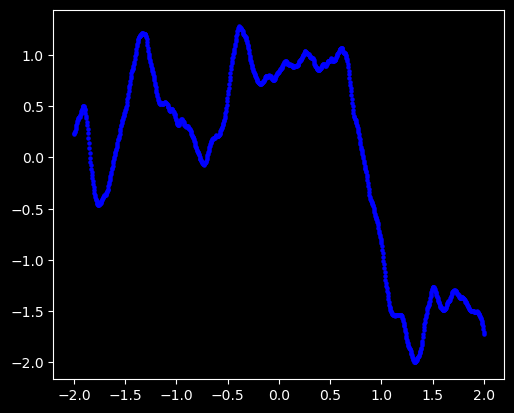

In [3]:
nPts = 1000

x = np.linspace(-2, 2, nPts)
X = x[:, np.newaxis]

# linear data
#m = 1
#b = 0
#y = m*x + b + np.random.normal(0, 0.1, nPts)

# sin data
#y = np.sin(2*np.pi*x/2) + np.random.normal(0, 0.1, nPts)

# smoothe random data
window = 30
y = pd.Series(np.random.randn(nPts+window-1)).cumsum().rolling(window=window).mean().dropna()
y = y / y.abs().max() * 2
y = y.values

plt.scatter(x, y, c='b', s=5)
plt.gca().set_aspect('equal')
plt.show()

## 3. Modeling

### 3.1 Preprocessing

Networks train best when inputs and targets are on a modest, comparable scale, because the
gradients of every weight then have comparable magnitude. Our synthetic `x` already lives in
$[-2, 2]$ and `y` is scaled to roughly the same range, so no scaling is needed here. The cell
below shows what target scaling would look like if it were - note that a scaled target must be
inverse-transformed before its predictions mean anything.

In [4]:
"""
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
y = scaler.fit_transform(y[:, np.newaxis])[:,0]
""";

### 3.2 Train/test split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2)

### 3.3 Create models

This is where a network gets defined, so this is where the architecture math belongs.

#### How a network computes

A neural network is composed of **layers** of neurons. Each layer $l$ applies a linear
transformation followed by a nonlinear activation function.

Let $\mathbf{a}^{(0)} = \mathbf{x} \in \mathbb{R}^d$ be the input (with $d$ features). For each
hidden layer $l = 1, \ldots, L-1$:

$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$$

$$\mathbf{a}^{(l)} = f\!\left(\mathbf{z}^{(l)}\right)$$

where $\mathbf{W}^{(l)} \in \mathbb{R}^{n_l \times n_{l-1}}$ is the weight matrix,
$\mathbf{b}^{(l)} \in \mathbb{R}^{n_l}$ is the bias vector, and $f$ is the activation function
applied element-wise. Each `Dense(n)` in the cell below is one such layer.

#### Activation functions

**ReLU** (hidden layers) introduces nonlinearity while avoiding the vanishing gradient problem:

$$f(z) = \max(0, z)$$

**tanh** is a smooth, saturating alternative, useful when you want bounded hidden activations:

$$f(z) = \tanh(z) = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}}$$

The nonlinearity is what makes the whole thing worth doing. Stack two linear layers with no
activation between them and you get $\mathbf{W}^{(2)}\mathbf{W}^{(1)}\mathbf{x}$, which is just
another linear model. With ReLU in between, each hidden unit contributes a "hinge" at a different
location, and summing many hinges lets the network trace out an arbitrary curve. This is the
informal statement of the **universal approximation theorem**: a network with one sufficiently wide
hidden layer can approximate any continuous function on a bounded interval to any desired accuracy.

#### The output layer

This is the one structural difference between a regression network and a classification network. A
classifier ends in $K$ softmax units that produce a probability distribution over classes. A
**regressor ends in a single unit with a linear (identity) activation**, so its output is free to
take any real value:

$$\hat{y} = \mathbf{w}^{(L)\top} \mathbf{a}^{(L-1)} + b^{(L)}$$

Squashing this last layer with `sigmoid` or `tanh` would cap the prediction to $(0,1)$ or $(-1,1)$,
which is only appropriate if the target has already been scaled into that range.

#### The loss

There is no cross-entropy here because there are no probabilities. We measure how far the
prediction is from the truth, in the units of the target itself.

**Mean squared error** (`'mse'`, `'mean_squared_error'`) is the default choice:

$$\mathcal{L}_{\text{MSE}} = \frac{1}{N} \sum_{i=1}^{N} \left(y_i - \hat{y}_i\right)^2$$

**Mean absolute error** (`'mae'`) squares nothing, so a single bad point pulls the fit far less:

$$\mathcal{L}_{\text{MAE}} = \frac{1}{N} \sum_{i=1}^{N} \left|y_i - \hat{y}_i\right|$$

Squaring makes MSE punish large residuals disproportionately, which is exactly what you want when
big misses are much worse than small ones, and exactly what you do **not** want when the data
contain outliers you would rather the model ignore.

#### The two models below

`model1` has a single layer, which makes it (almost) a linear model — one affine map followed by
one `tanh`. `model2` stacks five hidden ReLU layers before a linear output unit. Watch what the
extra depth buys us.

Both end in a `Dense` layer with **one** unit. That is the regression signature: one number out,
unbounded.

In [6]:
X.shape

(1000, 1)

In [7]:
#!pip isntall tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

In [8]:
# Model 1
model = Sequential([
    Input(shape=X.shape[1:]),
    Dense(units=1, activation='tanh'),
])

model.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mse']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471 (1.84 KB)

 Trainable params: 471 (1.84 KB)

 Non-trainable params: 0 (0.00 B)

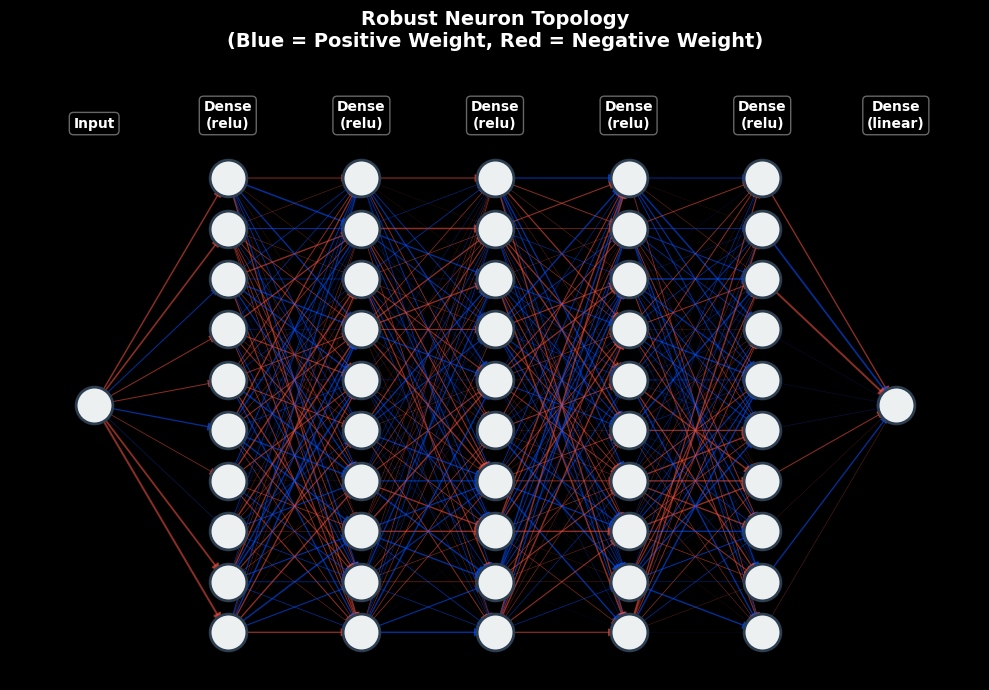

In [9]:
from tensorflow.keras.optimizers import Adam

# Model 2
model = Sequential([
    Input(shape=X.shape[1:]),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.01),
              loss='mean_squared_error')

model.summary()

# Draw the untrained network: weights are small random values, so every edge is thin.
plot_robust_neuron_network(model)

### 3.4 Train model

`model.fit(...)` runs the optimization, so this is where the training math belongs.

#### Backpropagation

Training minimizes $\mathcal{L}$ by computing gradients of the loss with respect to every weight
via the **chain rule**:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}} =
\frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(l)}} \cdot
\left(\mathbf{a}^{(l-1)}\right)^\top$$

The error signal
$\boldsymbol{\delta}^{(l)} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(l)}}$ propagates
**backward** from the output layer to the input layer, giving the algorithm its name. Keras does
this for us on every batch; the only visible sign of it is the loss going down.

#### Optimizer: Adam

**Adam** (Adaptive Moment Estimation) maintains per-parameter learning rates using running estimates
of the first moment (mean) $m_t$ and second moment (uncentered variance) $v_t$ of the gradients:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1)\, g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2)\, g_t^2$$

The bias-corrected update rule for each parameter $\theta$ is:

$$\theta_t = \theta_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

where $\alpha$ is the learning rate (set to `0.01` when the model was compiled above), and
$\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-7}$ are standard defaults. Adam is robust to
the choice of learning rate and is the most common optimizer for deep learning — though "robust"
is not "indifferent", as `U1-3_Regression-6_KerasLossVsLR` shows by sweeping $\alpha$ over six
orders of magnitude.

#### One epoch, one batch

`epochs=100` means the optimizer sees the whole training set 100 times; `batch_size=32` means the
weights are updated after every 32 examples rather than after the whole set. Watch the training and
validation loss in the output, and compare them — a validation loss that stops falling while the
training loss keeps dropping is the overfitting signature from `U1-3_Regression-2_Overfitting`.

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    #steps_per_epoch=10,
    shuffle=True,
    validation_data=(X_test, y_test),
    verbose=1,
)

Epoch 1/100


 1/25 ━━━━━━━━━━━━━━━━━━━━ 22s 940ms/step - loss: 0.8293

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4822 - val_loss: 0.2612


Epoch 2/100


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2551

...

 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0209

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0173 - val_loss: 0.0214


Epoch 100/100


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0277

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0190 - val_loss: 0.0139


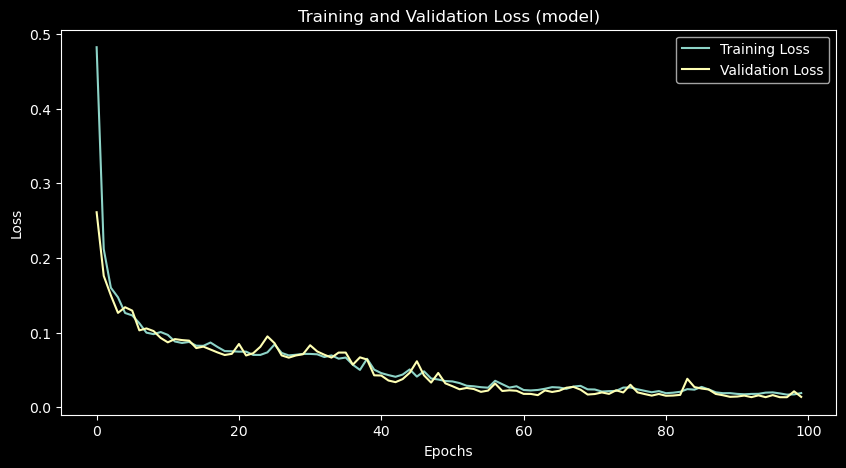

In [11]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (model)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.ylim(0,max(max(history.history['loss']),max(history.history['val_loss'])))
plt.legend()

### 3.5 The network after training

Draw the same network again now that it has been fit. Compare it to the diagram above: the
initial weights were small random values, so every edge was thin and the colors were scattered
at random. After training, some paths through the network have thickened into the dominant
route from input to output, others have collapsed toward zero, and whole neurons may have gone
effectively dead (no thick edges leaving them). That structure *is* the learned function.

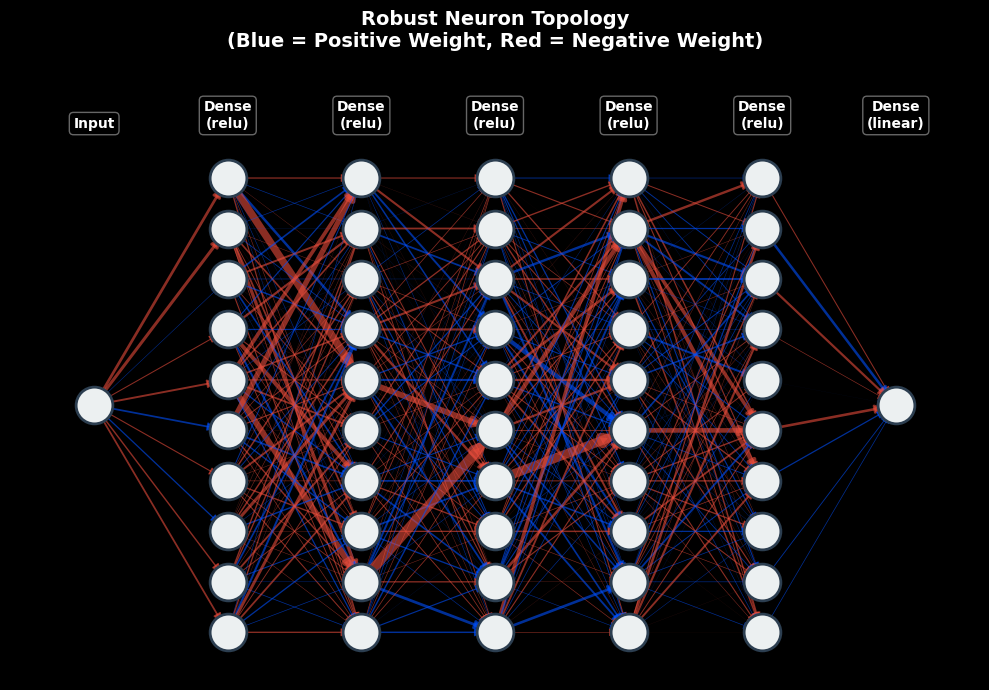

In [12]:
# The same architecture, now with trained weights.
plot_robust_neuron_network(model)

### 3.6 Check model performance

In [13]:
y_pred = model.predict(X)[:,0]
y_pred[:5]

 1/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([-0.0804406 , -0.08050518, -0.08057   , -0.08063484, -0.08069954],
      dtype=float32)

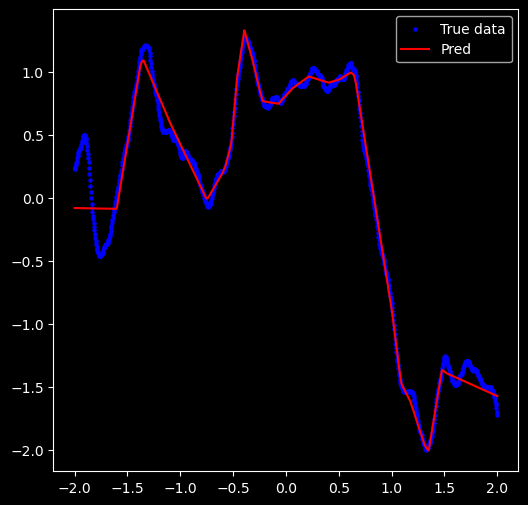

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(x, y, c='b', s=5, label="True data")
plt.plot( x, y_pred, 'r', label="Pred" )
#plt.gca().set_aspect('equal')
plt.legend()
plt.show()

### 3.7 Extrapolate model beyond training limits

This is the most important plot in the notebook. Inside the training range the network traces
the data closely. Outside it, the prediction is whatever the final layer's linear combination of
saturated/unbounded ReLU units happens to produce - typically a straight line shooting off in
some arbitrary direction. The network learned the *data*, not the *process that generated it*,
and nothing in the loss function ever asked it to behave sensibly where it saw no data.

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


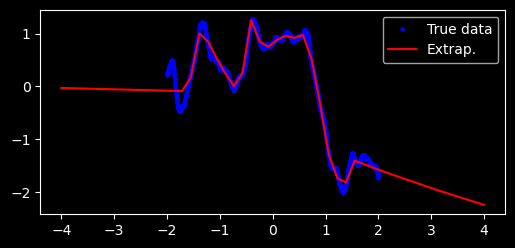

In [15]:
x_ext = np.linspace(-4,4,50)
X_ext = x_ext[:,np.newaxis]
#X_ext = X_ext % 2

y_ext = model.predict(X_ext)

plt.figure(figsize=(6,6))
plt.scatter(x, y, c='b', s=5, label="True data")
plt.plot( x_ext, y_ext, 'r', label="Extrap." )
plt.gca().set_aspect('equal')
plt.legend()
plt.show()

### 3.8 Examine model weights

The diagram is the intuition; these are the actual numbers behind it.

In [16]:
for i, layer in enumerate(model.layers):
    print(f"Weights of layer {i}:")
    print(f'\tWeights: {layer.get_weights()[0]}')
    print(f'\tBiasess: {layer.get_weights()[1]}')
    print()
# end

Weights of layer 0:
	Weights: [[-0.9833071  -1.0946189   0.17938124 -0.37453383 -0.69335663  0.62670946
  -0.40083432  0.466739   -0.5168237  -0.6337723 ]]
	Biasess: [-0.2150711  -0.50882304  0.0069229   0.5715023  -0.9471126   0.04403272
 -0.44094548 -0.23313813 -0.130602   -0.14781664]

Weights of layer 1:
	Weights: [[-0.44075122  0.21559131 -0.10876873  0.8874454  -2.691417    0.06370123
   0.18266213 -0.18716206  0.13921683 -0.4346838 ]
 [ 0.2123002   0.06117352 -0.14250425  0.28077048 -0.594141   -0.03168398
  -0.3275066  -0.6302112  -1.1592448  -0.24970004]
 [ 0.6010155  -0.69970834  0.19593221  0.5341452  -0.0410886  -0.29060987
   0.568526    0.0962829   0.06058588 -0.41581967]
 [ 0.41731596 -0.8046187   0.05595535  0.44726142 -0.05789899 -0.41122815
  -1.4274561  -0.22629394  0.7209617  -0.32280695]
 [-1.3314267  -0.5882874   0.18655747 -0.58602816 -0.39551872 -0.6476557
   0.4694226  -0.15177192 -2.123386    0.43836778]
 [-1.889286    0.24215785 -0.21695475 -0.3518112  -0.421

## 4. The course helper: `train_and_evaluate`

Everything we just did by hand - `model.fit(...)`, plotting the loss curve, plotting predictions,
printing metrics - is a pattern we will repeat in every Keras notebook. The course repo keeps
that pattern in one shared module, `msds565_helpers.py`, at the repository root. Notebooks sit
two folders below the root, so `'../..'` points back to it.

From here on, other notebooks call `helpers.train_and_evaluate(...)` instead of re-writing the
loop. You have now seen exactly what is inside it.

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


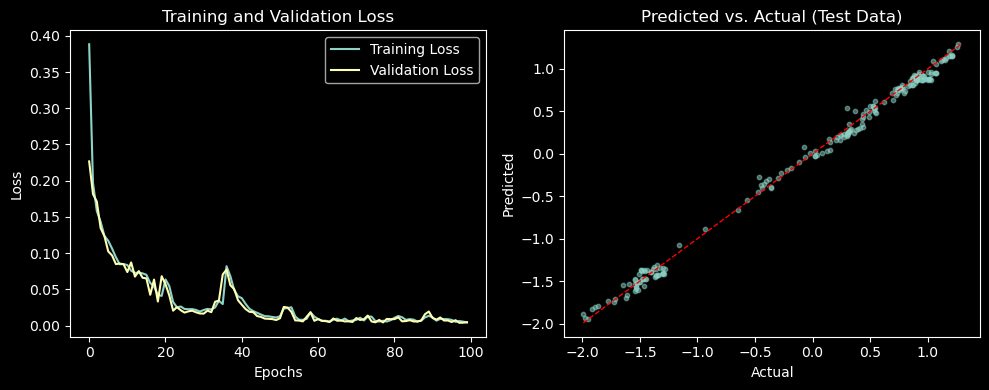

Test-set regression metrics
  MSE : 0.0045
  MAE : 0.0538
  R^2 : 0.9957


In [17]:
# A fresh copy of Model 2, trained and evaluated in one call.
model = Sequential([
    Input(shape=X.shape[1:]),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer=Adam(learning_rate=0.01),
              loss='mean_squared_error')

model, history = helpers.train_and_evaluate(
    model, X_train, y_train, X_test, y_test,
    epochs=100, batch_size=32, verbose=0
)

## 5. Watching the network learn

A loss curve tells us training worked; it does not tell us *how*. Here we capture two snapshots
after every epoch with a Keras callback — the model's predictions across the whole input range, and
the state of all its weights — and render them side by side as an animated GIF.

The left panel shows the fit sweeping into place: an early network is a nearly flat line, then the
ReLU hinges slide into position one at a time until the curve locks onto the data. The right panel
shows the weight graph over the same epochs, so you can watch edges thicken as they become important
and fade as they become irrelevant.

This cell carries **the same three generators as section 2** — line, sine, and smoothed random walk —
again toggled by comment. The sine is active here because it is the easiest of the three to follow
frame by frame: the fit visibly wraps onto a shape you already know. The random walk is worth
running too, and is more dramatic, since the network has to find structure with no closed form; the
line converges almost immediately and makes for a short animation.

The network is also deliberately small, so the weight diagram stays readable frame to frame.

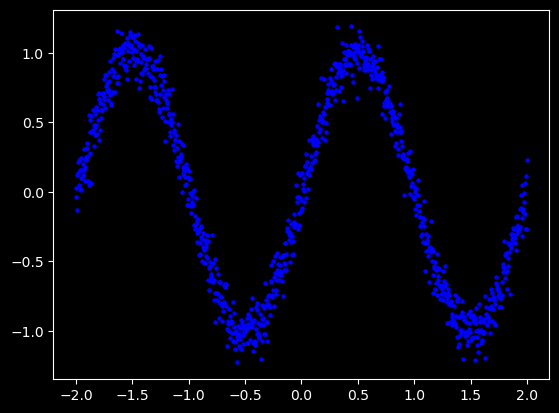

In [18]:
import matplotlib.animation as animation
import tensorflow as tf

# ==========================
# 1. Data Generation
# ==========================

nPts = 1000

x = np.linspace(-2, 2, nPts)
X = x[:, np.newaxis]

# linear data
#m = 1
#b = 0
#y = m*x + b + np.random.normal(0, 0.1, nPts)

# sin data
y = np.sin(2*np.pi*x/2) + np.random.normal(0, 0.1, nPts)

# smoothe random data
#window = 50
#y = pd.Series(np.random.randn(nPts+window-1)).cumsum().rolling(window=window).mean().dropna()
#y = y / y.abs().mean()
#y = y.values + np.random.randn(nPts) * 0.05

plt.scatter(x, y, c='b', s=5)
plt.show()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

...

 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1671

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1532 


Epoch 150/150


 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1887

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1541 


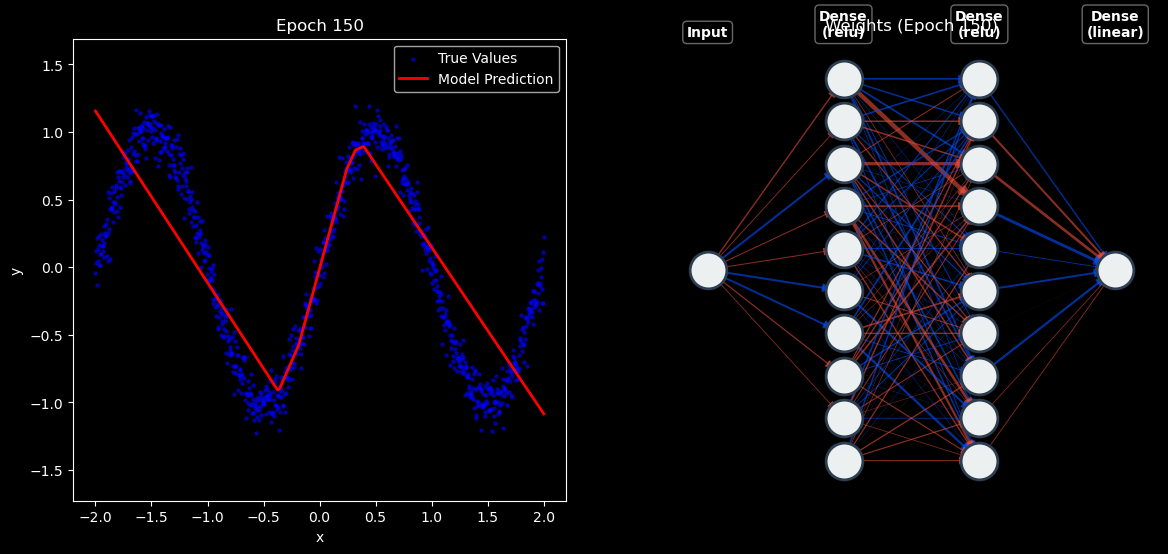

done


In [19]:
# ==========================
# 2. Model Definition
# ==========================

# Kept small on purpose: 1 -> 10 -> 10 -> 1 is enough to fit a sine wave,
# and few enough neurons that the weight diagram is readable frame by frame.
model = Sequential([
    Input(shape=X.shape[1:]),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1,  activation='linear'),
])

learning_rate = 0.005
model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss='mse'
)

model.summary()

# ==========================
# 3. Training while recording snapshots
# ==========================

predictions_per_epoch = []   # model output across all of X, once per epoch
weights_per_epoch = []       # (layer_sizes, layer_weights, layer_labels), once per epoch

class EpochCallback(tf.keras.callbacks.Callback):
    """Custom Keras callback to save predictions and weights after each epoch."""
    def on_epoch_end(self, epoch, logs=None):
        predictions_per_epoch.append(model.predict(X, verbose=0).flatten())
        weights_per_epoch.append(_get_model_graph_data(model))

epochs = 150
model.fit(
    X, y,
    epochs=epochs,
    batch_size=64,
    verbose=1,
    callbacks=[EpochCallback()]
)

# ==========================
# 4. Animation & Saving GIF
# ==========================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: the data and the current fit.
axes[0].scatter(x, y, color='b', s=5, label='True Values', alpha=0.5)
line, = axes[0].plot(x, predictions_per_epoch[0], 'r', lw=2, label='Model Prediction')
axes[0].set_ylim(y.min() - 0.5, y.max() + 0.5)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(loc='upper right')
axes[0].set_title('Epoch 1')

# Right panel: the weights (initial draw).
_draw_network_on_ax(*weights_per_epoch[0], axes[1])
axes[1].set_title('Weights (Epoch 1)')

def update(epoch):
    """Redraw both panels for one epoch."""
    line.set_data(x, predictions_per_epoch[epoch])
    axes[0].set_title(f'Epoch {epoch + 1}')
    axes[1].clear()
    _draw_network_on_ax(*weights_per_epoch[epoch], axes[1])
    axes[1].set_title(f'Weights (Epoch {epoch + 1})')
    return line,

ani = animation.FuncAnimation(fig, update, frames=epochs, interval=50, blit=False)

# Save animation as a GIF
gif_filename = "regression_training.gif"
ani.save(gif_filename, writer='pillow', fps=5)
plt.show()

print("done")

![regression training animation](regression_training.gif)

## 6. Review

- A feedforward network is a stack of affine maps $\mathbf{W}^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$
  separated by nonlinear activations. Remove the activations and the whole stack collapses back
  into a single linear model.
- A **regression** network ends in one `Dense(1, activation='linear')` unit and is trained with
  `'mse'` or `'mae'`. This is the only structural change from the classification network, which
  ends in `Dense(K, activation='softmax')` with cross-entropy loss.
- Depth and width buy flexibility: `model1` (one `tanh` unit) can only bend the data one way,
  while `model2` (five ReLU layers) traces a wiggly random walk closely.
- Training is backpropagation plus Adam. Adam's per-parameter adaptive step sizes are why it
  works well across a wide range of learning rates.
- The weight graph makes learning visible. Training turns an evenly-thin random initialization
  into a few dominant pathways, with other neurons going effectively dead.
- Networks **interpolate, they do not extrapolate**. Predictions outside the training range are
  unconstrained by the loss and should not be trusted.
- `helpers.train_and_evaluate(...)` packages the fit-plot-report loop used from here on.